In [1]:
import os
import re
import glob
import json
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


def repo_root() -> Path:
    """Return the repository root containing downloaded artifact directories."""
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "data_model_weights").is_dir() or (cand / "scripts" / "download_artifact.py").is_file():
            return cand
    raise FileNotFoundError("Could not find repo root. Run this notebook from inside the repository.")


REPO_ROOT = repo_root()
DATA_MODEL_WEIGHTS_DIR = REPO_ROOT / "data_model_weights"


# =============================================================================
# Model class definitions (TopK SAE from https://arxiv.org/abs/2406.04093)
# =============================================================================

@torch.no_grad()
def set_decoder_norm_to_unit_norm(W_dec, activation_dim, dict_size):
    D, F = W_dec.shape
    assert D == activation_dim, f"Expected activation_dim={activation_dim}, got {D}"
    assert F == dict_size, f"Expected dict_size={dict_size}, got {F}"
    eps = torch.finfo(W_dec.dtype).eps
    norm = torch.norm(W_dec.data, dim=0, keepdim=True)
    W_dec.data /= norm + eps
    return W_dec.data


class AutoEncoderTopK(nn.Module):
    """
    Top-k autoencoder from https://arxiv.org/abs/2406.04093
    """

    def __init__(self, activation_dim: int, dict_size: int, k: int):
        super().__init__()
        self.activation_dim = activation_dim
        self.dict_size = dict_size

        assert isinstance(k, int) and k > 0, f"k={k} must be a positive integer"
        self.register_buffer("k", torch.tensor(k, dtype=torch.int))
        self.register_buffer("threshold", torch.tensor(-1.0, dtype=torch.float32))

        self.decoder = nn.Linear(dict_size, activation_dim, bias=False)
        self.encoder = nn.Linear(activation_dim, dict_size)
        self.b_dec = nn.Parameter(torch.zeros(activation_dim))

    def encode(self, x: torch.Tensor, return_topk: bool = False, use_threshold: bool = False):
        post_relu_feat_acts_BF = F.relu(self.encoder(x - self.b_dec))

        if use_threshold:
            encoded_acts_BF = post_relu_feat_acts_BF * (post_relu_feat_acts_BF > self.threshold)
            if return_topk:
                post_topk = post_relu_feat_acts_BF.topk(self.k, sorted=False, dim=-1)
                return encoded_acts_BF, post_topk.values, post_topk.indices, post_relu_feat_acts_BF
            else:
                return encoded_acts_BF

        post_topk = post_relu_feat_acts_BF.topk(self.k, sorted=False, dim=-1)
        tops_acts_BK = post_topk.values
        top_indices_BK = post_topk.indices

        buffer_BF = torch.zeros_like(post_relu_feat_acts_BF)
        encoded_acts_BF = buffer_BF.scatter_(dim=-1, index=top_indices_BK, src=tops_acts_BK)

        if return_topk:
            return encoded_acts_BF, tops_acts_BK, top_indices_BK, post_relu_feat_acts_BF
        else:
            return encoded_acts_BF

    def decode(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(x) + self.b_dec

    def forward(self, x: torch.Tensor, output_features: bool = False):
        encoded_acts_BF = self.encode(x)
        x_hat_BD = self.decode(encoded_acts_BF)
        if not output_features:
            return x_hat_BD
        else:
            return x_hat_BD, encoded_acts_BF

    @staticmethod
    def from_pretrained(path, k=None, device=None):
        """Load a pretrained autoencoder from a file."""
        state_dict = torch.load(path, map_location='cpu')
        dict_size, activation_dim = state_dict["encoder.weight"].shape

        if k is None:
            k = state_dict["k"].item()
        elif "k" in state_dict and k != state_dict["k"].item():
            raise ValueError(f"k={k} != {state_dict['k'].item()}=state_dict['k']")

        autoencoder = AutoEncoderTopK(activation_dim, dict_size, k)
        autoencoder.load_state_dict(state_dict)
        if device is not None:
            autoencoder.to(device)
        return autoencoder


In [2]:
def load_config(config_path):
    """
    Load and parse a config.json file.
    Returns dict with relevant hyperparameters.
    """
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    trainer_config = config.get('trainer', {})
    
    return {
        'seed': trainer_config.get('seed'),
        'k': trainer_config.get('k'),
        'l2_w': trainer_config.get('l2_w'),
        'activation_dim': trainer_config.get('activation_dim'),
        'dict_size': trainer_config.get('dict_size'),
        'steps': trainer_config.get('steps'),
        'layer': trainer_config.get('layer'),
        'lm_name': trainer_config.get('lm_name'),
        'submodule_name': trainer_config.get('submodule_name'),
    }


def find_models_with_configs(model_dir):
    """
    Find all ae.pt files and their associated config.json files.
    Returns list of dicts with model path and parsed config.
    """
    models = []
    
    # Find all config.json files
    config_files = glob.glob(os.path.join(model_dir, '**', 'config.json'), recursive=True)
    
    for config_path in config_files:
        trainer_dir = os.path.dirname(config_path)
        model_path = os.path.join(trainer_dir, 'ae.pt')
        
        if os.path.exists(model_path):
            config = load_config(config_path)
            config['model_path'] = model_path
            config['config_path'] = config_path
            models.append(config)
    
    return models


def group_models_by_config(model_dir):
    """
    Group models by their configuration (k, l2_w), excluding seed.
    Returns a dict: config_key -> list of (seed, model_path, full_config)
    """
    models = find_models_with_configs(model_dir)
    
    grouped = defaultdict(list)
    
    for model_info in models:
        # Create config key (k and l2_w - the hyperparameters that vary)
        config_key = (
            model_info['k'],
            model_info['l2_w'],
        )
        grouped[config_key].append((model_info['seed'], model_info['model_path'], model_info))
    
    # Sort by seed within each group (handle None seeds by placing them at the end)
    for key in grouped:
        grouped[key].sort(key=lambda x: (x[0] is None, x[0] if x[0] is not None else 0))
    
    return dict(grouped)


# Load and group models
model_dirs = [
    DATA_MODEL_WEIGHTS_DIR / "random_seeds_constrained_saes_EleutherAI_pythia-70m-deduped_top_k_l2"
]

all_grouped = {}
for model_dir in model_dirs:
    model_dir = str(model_dir)
    if os.path.exists(model_dir):
        grouped = group_models_by_config(model_dir)
        all_grouped.update(grouped)

# Display discovered configurations
print("Discovered configurations (with multiple seeds):")
print("=" * 80)
for config, seeds_files in sorted(all_grouped.items()):
    if len(seeds_files) >= 2:  # Only show configs with multiple seeds
        k, l2_w = config
        seeds = [s for s, _, _ in seeds_files]
        print(f"k={k}, l2_w={l2_w}")
        print(f"  Seeds: {seeds}")
        print()


Discovered configurations (with multiple seeds):
k=40, l2_w=0
  Seeds: [0, 1, 2]

k=40, l2_w=0.0001
  Seeds: [0, 1, 2]

k=80, l2_w=0
  Seeds: [0, 1, 2]

k=80, l2_w=0.0001
  Seeds: [0, 1, 2]

k=150, l2_w=0
  Seeds: [0, 1, 2]

k=150, l2_w=0.0001
  Seeds: [0, 1, 2]

k=320, l2_w=0
  Seeds: [0, 1, 2]

k=320, l2_w=0.0001
  Seeds: [0, 1, 2]



In [3]:
# =============================================================================
# Decoder Orthogonality Analysis Functions
# =============================================================================

def compute_decoder_gram_matrix(model):
    """
    Compute the Gram matrix D^T @ D for the decoder weights.
    Since decoder columns are unit-normalized, this gives cosine similarities.
    
    Returns: (dict_size, dict_size) tensor of cosine similarities
    """
    # Decoder weight shape: (activation_dim, dict_size)
    D = model.decoder.weight.data
    
    # Normalize columns to unit norm (should already be normalized, but just in case)
    D_normalized = F.normalize(D, dim=0)
    
    # Gram matrix: D^T @ D gives (dict_size, dict_size) matrix of cosine similarities
    gram = D_normalized.T @ D_normalized
    
    return gram


def compute_orthogonality_metrics(gram_matrix):
    """
    Compute various orthogonality metrics from the Gram matrix.
    """
    n = gram_matrix.shape[0]
    
    # Get off-diagonal elements (exclude self-similarities on diagonal)
    mask = ~torch.eye(n, dtype=torch.bool, device=gram_matrix.device)
    off_diag = gram_matrix[mask]
    
    # Compute metrics
    metrics = {
        'mean_abs_cosine': np.abs(off_diag.cpu().numpy()).mean(),
        'max_abs_cosine': np.abs(off_diag.cpu().numpy()).max(),
        'std_cosine': off_diag.cpu().numpy().std(),
        'mean_cosine': off_diag.cpu().numpy().mean(),
        'median_abs_cosine': np.median(np.abs(off_diag.cpu().numpy())),
        'frobenius_deviation': (gram_matrix - torch.eye(n, device=gram_matrix.device)).norm().item(),
        'num_features': n,
        # Percentiles of absolute cosine similarities
        'p90_abs_cosine': float(np.percentile(np.abs(off_diag.cpu().numpy()), 90)),
        'p99_abs_cosine': float(np.percentile(np.abs(off_diag.cpu().numpy()), 99)),
    }
    
    return metrics, off_diag.cpu().numpy()


def analyze_model_orthogonality(model_path, device=None):
    """
    Load a model and compute its decoder orthogonality metrics.
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = AutoEncoderTopK.from_pretrained(model_path, device=device)
    model.eval()
    
    gram = compute_decoder_gram_matrix(model)
    metrics, cosine_dist = compute_orthogonality_metrics(gram)
    
    return metrics, cosine_dist, gram.cpu().numpy()


# Test on one model
test_config = list(all_grouped.keys())[0]
test_seed, test_path, test_info = all_grouped[test_config][0]

print(f"Testing on model: k={test_info['k']}, l2_w={test_info['l2_w']}, seed={test_seed}")
test_metrics, test_cosines, test_gram = analyze_model_orthogonality(test_path)

print("\nOrthogonality Metrics:")
for key, val in test_metrics.items():
    print(f"  {key}: {val:.6f}" if isinstance(val, float) else f"  {key}: {val}")

Testing on model: k=40, l2_w=0, seed=0

Orthogonality Metrics:
  mean_abs_cosine: 0.04310879483819008
  max_abs_cosine: 0.99861079454422
  std_cosine: 0.05457357317209244
  mean_cosine: 0.002912485972046852
  median_abs_cosine: 0.03585759922862053
  frobenius_deviation: 855.668396
  num_features: 16384
  p90_abs_cosine: 0.089431
  p99_abs_cosine: 0.146184


In [4]:
# =============================================================================
# Analyze All Configurations (only seed=1 per config)
# =============================================================================

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

all_results = []

for config, seeds_files in sorted(all_grouped.items()):
    k, l2_w = config

    # Only analyze the model with seed==1 (if it exists)
    found = False
    for seed, model_path, model_info in seeds_files:
        if seed == 1:
            print(f"Analyzing k={k}, l2_w={l2_w}, seed={seed}...", end=" ")

            try:
                metrics, cosine_dist, gram = analyze_model_orthogonality(model_path, device=device)

                result = {
                    'k': k,
                    'l2_w': l2_w,
                    'seed': seed,
                    'model_path': model_path,
                    **metrics,
                    'cosine_distribution': cosine_dist,
                }
                all_results.append(result)
                print(f"Mean |cos|={metrics['mean_abs_cosine']:.4f}")

            except Exception as e:
                print(f"ERROR: {e}")
            found = True
            break
    if not found:
        print(f"No seed=1 for k={k}, l2_w={l2_w}")

print(f"\nTotal models analyzed: {len(all_results)}")

Using device: cpu
Analyzing k=40, l2_w=0, seed=1... Mean |cos|=0.0429
Analyzing k=40, l2_w=0.0001, seed=1... Mean |cos|=0.0361
Analyzing k=80, l2_w=0, seed=1... Mean |cos|=0.0392
Analyzing k=80, l2_w=0.0001, seed=1... Mean |cos|=0.0357
Analyzing k=150, l2_w=0, seed=1... Mean |cos|=0.0374
Analyzing k=150, l2_w=0.0001, seed=1... Mean |cos|=0.0353
Analyzing k=320, l2_w=0, seed=1... Mean |cos|=0.0352
Analyzing k=320, l2_w=0.0001, seed=1... Mean |cos|=0.0351

Total models analyzed: 8


In [5]:
# =============================================================================
# Create Summary DataFrame
# =============================================================================
import pandas as pd

# Create DataFrame (excluding the distribution arrays)
df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'cosine_distribution'} 
                           for r in all_results])

# Add l2_w label column for easier plotting
df_results['l2_w_label'] = df_results['l2_w'].apply(lambda x: f'L2={x}')

# Aggregate by config (k, l2_w) - mean and std across seeds
agg_results = df_results.groupby(['k', 'l2_w']).agg({
    'mean_abs_cosine': ['mean', 'std'],
    'max_abs_cosine': ['mean', 'std'],
    'median_abs_cosine': ['mean', 'std'],
    'p90_abs_cosine': ['mean', 'std'],
    'p99_abs_cosine': ['mean', 'std'],
    'frobenius_deviation': ['mean', 'std'],
}).round(6)

print("Aggregated Results by Configuration:")
print("=" * 80)
display(agg_results)

Aggregated Results by Configuration:


mean_abs_cosine     max_abs_cosine     median_abs_cosine      \
                      mean std           mean std              mean std   
k   l2_w                                                                  
40  0.0000        0.042945 NaN       0.998371 NaN          0.035727 NaN   
    0.0001        0.036086 NaN       0.997105 NaN          0.030454 NaN   
80  0.0000        0.039169 NaN       0.996073 NaN          0.032862 NaN   
    0.0001        0.035721 NaN       0.997967 NaN          0.030184 NaN   
150 0.0000        0.037396 NaN       0.981787 NaN          0.031416 NaN   
    0.0001        0.035257 NaN       0.997656 NaN          0.029799 NaN   
320 0.0000        0.035224 NaN       0.761053 NaN          0.029772 NaN   
    0.0001        0.035142 NaN       0.985938 NaN          0.029711 NaN   

           p90_abs_cosine     p99_abs_cosine     frobenius_deviation      
                     mean std           mean std                mean std  
k   l2_w                                                                  
40  0.0000       0.089083 NaN       0.145430 NaN          852.153381 NaN  
    0.0001       0.074380 NaN       0.117182 NaN          715.051086 NaN  
80  0.0000       0.081054 NaN       0.129206 NaN          774.072754 NaN  
    0.0001       0.073618 NaN       0.115460 NaN          706.701965 NaN  
150 0.0000       0.077386 NaN       0.122767 NaN          741.184998 NaN  
    0.0001       0.072667 NaN       0.113827 NaN          696.869934 NaN  
320 0.0000       0.072636 NaN       0.113695 NaN          695.935547 NaN  
    0.0001       0.072447 NaN       0.113342 NaN          694.012512 NaN

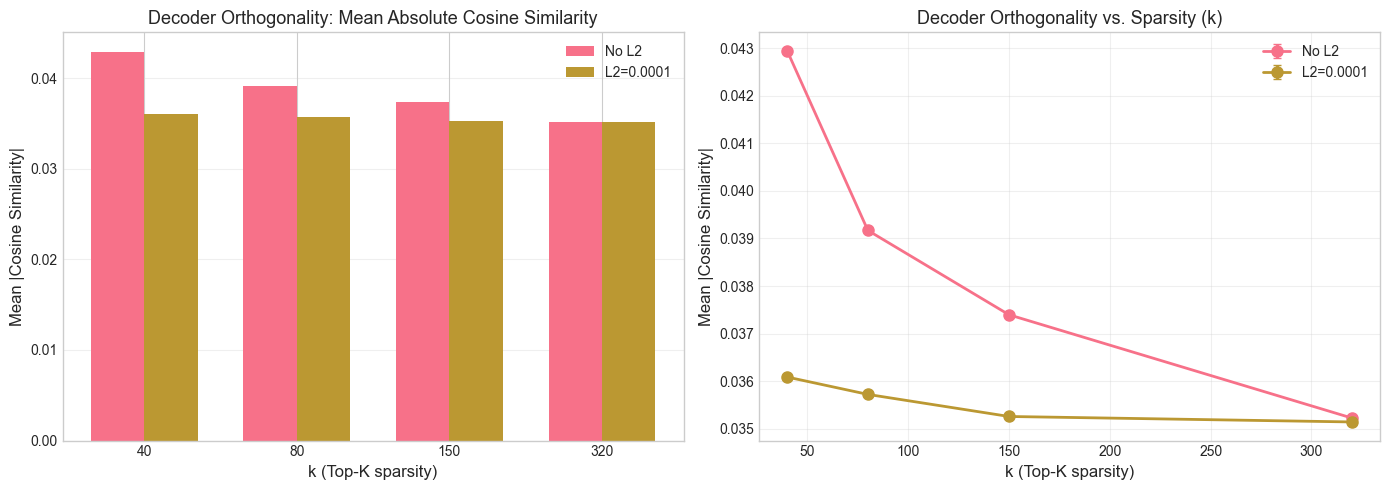

In [6]:
# =============================================================================
# Visualization: Mean Absolute Cosine Similarity by k and L2
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar plot of mean |cos| by k, grouped by l2_w
k_values = sorted(df_results['k'].unique())
l2_values = sorted(df_results['l2_w'].unique())

x = np.arange(len(k_values))
width = 0.35

for i, l2_w in enumerate(l2_values):
    subset = df_results[df_results['l2_w'] == l2_w].groupby('k')['mean_abs_cosine'].agg(['mean', 'std'])
    means = [subset.loc[k, 'mean'] if k in subset.index else 0 for k in k_values]
    stds = [subset.loc[k, 'std'] if k in subset.index else 0 for k in k_values]
    
    label = f'L2={l2_w}' if l2_w > 0 else 'No L2'
    axes[0].bar(x + i*width - width/2, means, width, yerr=stds, label=label, capsize=3)

axes[0].set_xlabel('k (Top-K sparsity)', fontsize=12)
axes[0].set_ylabel('Mean |Cosine Similarity|', fontsize=12)
axes[0].set_title('Decoder Orthogonality: Mean Absolute Cosine Similarity', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Line plot showing trend
for l2_w in l2_values:
    subset = df_results[df_results['l2_w'] == l2_w].groupby('k')['mean_abs_cosine'].agg(['mean', 'std'])
    label = f'L2={l2_w}' if l2_w > 0 else 'No L2'
    axes[1].errorbar(subset.index, subset['mean'], yerr=subset['std'], 
                     marker='o', capsize=3, label=label, linewidth=2, markersize=8)

axes[1].set_xlabel('k (Top-K sparsity)', fontsize=12)
axes[1].set_ylabel('Mean |Cosine Similarity|', fontsize=12)
axes[1].set_title('Decoder Orthogonality vs. Sparsity (k)', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# Summary Statistics & Analysis
# =============================================================================

print("=" * 80)
print("DECODER ORTHOGONALITY ANALYSIS SUMMARY")
print("=" * 80)

# Compare L2 regularization effect
print("\n1. Effect of L2 Regularization on Orthogonality:")
print("-" * 60)

for k in sorted(df_results['k'].unique()):
    subset = df_results[df_results['k'] == k]
    
    no_l2 = subset[subset['l2_w'] == 0]['mean_abs_cosine'].mean()
    with_l2 = subset[subset['l2_w'] > 0]['mean_abs_cosine'].mean()
    
    diff = with_l2 - no_l2
    pct_change = (diff / no_l2) * 100 if no_l2 > 0 else 0
    
    print(f"k={k:3d}: No L2={no_l2:.4f}, With L2={with_l2:.4f} | Δ={diff:+.4f} ({pct_change:+.1f}%)")

# Effect of k on orthogonality
print("\n2. Effect of Sparsity (k) on Orthogonality:")
print("-" * 60)

for l2_w in sorted(df_results['l2_w'].unique()):
    l2_label = f"L2={l2_w}" if l2_w > 0 else "No L2"
    subset = df_results[df_results['l2_w'] == l2_w]
    
    k_sorted = sorted(subset['k'].unique())
    values = [subset[subset['k'] == k]['mean_abs_cosine'].mean() for k in k_sorted]
    
    print(f"\n{l2_label}:")
    for k, v in zip(k_sorted, values):
        print(f"  k={k:3d}: Mean |cos| = {v:.4f}")

# Correlation between k and orthogonality
print("\n3. Correlation Analysis:")
print("-" * 60)
from scipy.stats import pearsonr, spearmanr

for l2_w in sorted(df_results['l2_w'].unique()):
    l2_label = f"L2={l2_w}" if l2_w > 0 else "No L2"
    subset = df_results[df_results['l2_w'] == l2_w]
    
    corr_pearson, p_pearson = pearsonr(subset['k'], subset['mean_abs_cosine'])
    corr_spearman, p_spearman = spearmanr(subset['k'], subset['mean_abs_cosine'])
    
    print(f"{l2_label}:")
    print(f"  Pearson r(k, mean|cos|)  = {corr_pearson:.3f} (p={p_pearson:.4f})")
    print(f"  Spearman ρ(k, mean|cos|) = {corr_spearman:.3f} (p={p_spearman:.4f})")

DECODER ORTHOGONALITY ANALYSIS SUMMARY

1. Effect of L2 Regularization on Orthogonality:
------------------------------------------------------------
k= 40: No L2=0.0429, With L2=0.0361 | Δ=-0.0069 (-16.0%)
k= 80: No L2=0.0392, With L2=0.0357 | Δ=-0.0034 (-8.8%)
k=150: No L2=0.0374, With L2=0.0353 | Δ=-0.0021 (-5.7%)
k=320: No L2=0.0352, With L2=0.0351 | Δ=-0.0001 (-0.2%)

2. Effect of Sparsity (k) on Orthogonality:
------------------------------------------------------------

No L2:
  k= 40: Mean |cos| = 0.0429
  k= 80: Mean |cos| = 0.0392
  k=150: Mean |cos| = 0.0374
  k=320: Mean |cos| = 0.0352

L2=0.0001:
  k= 40: Mean |cos| = 0.0361
  k= 80: Mean |cos| = 0.0357
  k=150: Mean |cos| = 0.0353
  k=320: Mean |cos| = 0.0351

3. Correlation Analysis:
------------------------------------------------------------
No L2:
  Pearson r(k, mean|cos|)  = -0.900 (p=0.1000)
  Spearman ρ(k, mean|cos|) = -1.000 (p=0.0000)
L2=0.0001:
  Pearson r(k, mean|cos|)  = -0.868 (p=0.1316)
  Spearman ρ(k, mean|

In [ ]:
# =============================================================================
# ALIVE FEATURES ANALYSIS: Filter Dead Features by Encoder-Decoder Alignment
# =============================================================================
# Following methodology from Braun et al. - a feature is "alive" if its 
# encoder-decoder alignment (cosine similarity) exceeds a threshold.
# Dead features have divergent encoder/decoder directions and shouldn't be
# counted in orthogonality analysis.

def compute_encoder_decoder_alignment(model):
    """
    Compute per-feature alignment between encoder and decoder weights.
    Returns cosine similarity between each encoder row and decoder column.
    
    High alignment = feature is "alive" and functioning normally
    Low alignment = feature is "dead" or not learning properly
    """
    # Encoder weight: (dict_size, activation_dim) - each row is a feature
    # Decoder weight: (activation_dim, dict_size) - each column is a feature
    enc = model.encoder.weight.data  # (dict_size, activation_dim)
    dec = model.decoder.weight.data  # (activation_dim, dict_size)
    
    # Normalize
    enc_norm = F.normalize(enc, dim=1)  # normalize each row
    dec_norm = F.normalize(dec, dim=0)  # normalize each column
    
    # Compute alignment: dot product of enc[i] with dec[:, i]
    # This gives cosine similarity between encoder direction and decoder direction for each feature
    alignment = (enc_norm * dec_norm.T).sum(dim=1)  # (dict_size,)
    
    return alignment.cpu().numpy()


def compute_alive_mask(model, threshold=0.2):
    """
    Return boolean mask of alive features (alignment > threshold).
    """
    alignment = compute_encoder_decoder_alignment(model)
    return alignment > threshold


def compute_decoder_gram_matrix_filtered(model, alive_mask):
    """
    Compute Gram matrix only for alive features.
    """
    D = model.decoder.weight.data  # (activation_dim, dict_size)
    D_alive = D[:, alive_mask]  # Filter to alive features
    
    D_normalized = F.normalize(D_alive, dim=0)
    gram = D_normalized.T @ D_normalized
    
    return gram


def analyze_model_orthogonality_filtered(model_path, alignment_threshold=0.2, device=None):
    """
    Load a model and compute decoder orthogonality for ALIVE features only.
    
    Args:
        model_path: Path to model checkpoint
        alignment_threshold: Features with enc-dec alignment > this are "alive"
        device: Device to use
    
    Returns:
        Dict with metrics for all features AND alive features
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model = AutoEncoderTopK.from_pretrained(model_path, device=device)
    model.eval()
    
    # Get alignment and alive mask
    alignment = compute_encoder_decoder_alignment(model)
    alive_mask = alignment > alignment_threshold
    n_alive = alive_mask.sum()
    n_total = len(alive_mask)
    
    # Compute metrics for ALL features (original analysis)
    gram_all = compute_decoder_gram_matrix(model)
    metrics_all, cosines_all = compute_orthogonality_metrics(gram_all)
    
    # Compute metrics for ALIVE features only
    if n_alive > 1:
        gram_alive = compute_decoder_gram_matrix_filtered(model, alive_mask)
        metrics_alive, cosines_alive = compute_orthogonality_metrics(gram_alive)
    else:
        metrics_alive = {k: np.nan for k in metrics_all.keys()}
        cosines_alive = np.array([])
    
    return {
        'n_alive': int(n_alive),
        'n_total': n_total,
        'frac_alive': n_alive / n_total,
        'alignment_mean': float(alignment.mean()),
        'alignment_std': float(alignment.std()),
        'alignment_distribution': alignment,
        # All features metrics
        'all_features': metrics_all,
        'all_cosines': cosines_all,
        # Alive features metrics
        'alive_features': metrics_alive,
        'alive_cosines': cosines_alive,
    }


# =============================================================================
# Run Analysis with Alive Feature Filtering (SEED=1 only)
# =============================================================================

ALIGNMENT_THRESHOLD = 0.1  # Standard threshold from Braun et al.

print("=" * 80)
print("DECODER ORTHOGONALITY: ALIVE FEATURES ANALYSIS (seed=1 only)")
print("=" * 80)
print(f"Filtering to features with encoder-decoder alignment > {ALIGNMENT_THRESHOLD}")
print()

filtered_results = []

for config, seeds_files in sorted(all_grouped.items()):
    k, l2_w = config
    
    for seed, model_path, model_info in seeds_files:
        if seed != 1:
            continue  # Only process seed = 1

        print(f"Analyzing k={k}, l2_w={l2_w}, seed={seed}...", end=" ")
        
        try:
            result = analyze_model_orthogonality_filtered(
                model_path, 
                alignment_threshold=ALIGNMENT_THRESHOLD,
                device=device
            )
            
            result['k'] = k
            result['l2_w'] = l2_w
            result['seed'] = seed
            result['model_path'] = model_path
            
            filtered_results.append(result)
            
            print(f"Alive: {result['n_alive']}/{result['n_total']} ({result['frac_alive']:.1%}), "
                  f"Mean|cos| all={result['all_features']['mean_abs_cosine']:.4f}, "
                  f"alive={result['alive_features']['mean_abs_cosine']:.4f}")
            
        except Exception as e:
            print(f"ERROR: {e}")

print(f"\nTotal models analyzed: {len(filtered_results)}")

DECODER ORTHOGONALITY: ALIVE FEATURES ANALYSIS (seed=1 only)
Filtering to features with encoder-decoder alignment > 0.1

Analyzing k=40, l2_w=0, seed=1... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0429, alive=0.0429
Analyzing k=40, l2_w=0.0001, seed=1... Alive: 1649/16384 (10.1%), Mean|cos| all=0.0361, alive=0.0422
Analyzing k=80, l2_w=0, seed=1... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0392, alive=0.0392
Analyzing k=80, l2_w=0.0001, seed=1... Alive: 1547/16384 (9.4%), Mean|cos| all=0.0357, alive=0.0349
Analyzing k=150, l2_w=0, seed=1... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0374, alive=0.0374
Analyzing k=150, l2_w=0.0001, seed=1... 

In [9]:
# =============================================================================
# Run Analysis with Alive Feature Filtering (ALL SEEDS)
# =============================================================================
# This reruns the seed=1 analysis above for every discovered seed and then
# replaces filtered_results so the existing comparison/plot cells aggregate all seeds.

print("=" * 80)
print("DECODER ORTHOGONALITY: ALIVE FEATURES ANALYSIS (all seeds)")
print("=" * 80)
print(f"Filtering to features with encoder-decoder alignment > {ALIGNMENT_THRESHOLD}")

all_discovered_seeds = sorted({seed for seeds_files in all_grouped.values() for seed, _, _ in seeds_files})
print(f"Analyzing seeds: {all_discovered_seeds}")
print()

filtered_results_all_seeds = []

for config, seeds_files in sorted(all_grouped.items()):
    k, l2_w = config
    
    for seed, model_path, model_info in seeds_files:
        print(f"Analyzing k={k}, l2_w={l2_w}, seed={seed}...", end=" ")
        
        try:
            result = analyze_model_orthogonality_filtered(
                model_path,
                alignment_threshold=ALIGNMENT_THRESHOLD,
                device=device,
            )
            
            result['k'] = k
            result['l2_w'] = l2_w
            result['seed'] = seed
            result['model_path'] = model_path
            
            filtered_results_all_seeds.append(result)
            
            print(f"Alive: {result['n_alive']}/{result['n_total']} ({result['frac_alive']:.1%}), "
                  f"Mean|cos| all={result['all_features']['mean_abs_cosine']:.4f}, "
                  f"alive={result['alive_features']['mean_abs_cosine']:.4f}")
            
        except Exception as e:
            print(f"ERROR: {e}")

print(f"\nTotal models analyzed: {len(filtered_results_all_seeds)}")

# Make downstream cells use the all-seed analysis without further changes.
filtered_results = filtered_results_all_seeds

DECODER ORTHOGONALITY: ALIVE FEATURES ANALYSIS (all seeds)
Filtering to features with encoder-decoder alignment > 0.1
Analyzing seeds: [0, 1, 2]

Analyzing k=40, l2_w=0, seed=0... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0431, alive=0.0431
Analyzing k=40, l2_w=0, seed=1... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0429, alive=0.0429
Analyzing k=40, l2_w=0, seed=2... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0429, alive=0.0429
Analyzing k=40, l2_w=0.0001, seed=0... Alive: 1603/16384 (9.8%), Mean|cos| all=0.0361, alive=0.0420
Analyzing k=40, l2_w=0.0001, seed=1... Alive: 1649/16384 (10.1%), Mean|cos| all=0.0361, alive=0.0422
Analyzing k=40, l2_w=0.0001, seed=2... Alive: 1657/16384 (10.1%), Mean|cos| all=0.0361, alive=0.0419
Analyzing k=80, l2_w=0, seed=0... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0392, alive=0.0392
Analyzing k=80, l2_w=0, seed=1... Alive: 16384/16384 (100.0%), Mean|cos| all=0.0392, alive=0.0392
Analyzing k=80, l2_w=0, seed=2... Alive: 16384/16384 (100.0%),

In [10]:
# =============================================================================
# Comparison: All Features vs Alive Features
# =============================================================================

# Create comparison DataFrame
comparison_data = []
for r in filtered_results:
    comparison_data.append({
        'k': r['k'],
        'l2_w': r['l2_w'],
        'seed': r['seed'],
        'frac_alive': r['frac_alive'],
        'alignment_mean': r['alignment_mean'],
        # All features
        'mean_abs_cos_all': r['all_features']['mean_abs_cosine'],
        'p90_abs_cos_all': r['all_features']['p90_abs_cosine'],
        'p99_abs_cos_all': r['all_features']['p99_abs_cosine'],
        # Alive features
        'mean_abs_cos_alive': r['alive_features']['mean_abs_cosine'],
        'p90_abs_cos_alive': r['alive_features']['p90_abs_cosine'],
        'p99_abs_cos_alive': r['alive_features']['p99_abs_cosine'],
    })

df_comparison = pd.DataFrame(comparison_data)

# Aggregate by config
print("=" * 80)
print("COMPARISON: All Features vs Alive Features")
print("=" * 80)

for (k, l2_w), group in df_comparison.groupby(['k', 'l2_w']):
    l2_label = f"L2={l2_w}" if l2_w > 0 else "No L2"
    
    print(f"\nk={k}, {l2_label}:")
    print(f"  Fraction alive:     {group['frac_alive'].mean():.1%} ± {group['frac_alive'].std():.1%}")
    print(f"  Mean alignment:     {group['alignment_mean'].mean():.3f}")
    print(f"  Mean |cos| ALL:     {group['mean_abs_cos_all'].mean():.4f}")
    print(f"  Mean |cos| ALIVE:   {group['mean_abs_cos_alive'].mean():.4f}")
    
    change = (group['mean_abs_cos_alive'].mean() - group['mean_abs_cos_all'].mean()) / group['mean_abs_cos_all'].mean() * 100
    print(f"  Change (alive):     {change:+.1f}%")

COMPARISON: All Features vs Alive Features

k=40, No L2:
  Fraction alive:     100.0% ± 0.0%
  Mean alignment:     0.803
  Mean |cos| ALL:     0.0430
  Mean |cos| ALIVE:   0.0430
  Change (alive):     +0.0%

k=40, L2=0.0001:
  Fraction alive:     10.0% ± 0.2%
  Mean alignment:     0.084
  Mean |cos| ALL:     0.0361
  Mean |cos| ALIVE:   0.0420
  Change (alive):     +16.5%

k=80, No L2:
  Fraction alive:     100.0% ± 0.0%
  Mean alignment:     0.851
  Mean |cos| ALL:     0.0392
  Mean |cos| ALIVE:   0.0392
  Change (alive):     +0.0%

k=80, L2=0.0001:
  Fraction alive:     9.5% ± 0.1%
  Mean alignment:     0.086
  Mean |cos| ALL:     0.0357
  Mean |cos| ALIVE:   0.0349
  Change (alive):     -2.5%

k=150, No L2:
  Fraction alive:     100.0% ± 0.0%
  Mean alignment:     0.867
  Mean |cos| ALL:     0.0374
  Mean |cos| ALIVE:   0.0374
  Change (alive):     +0.0%

k=150, L2=0.0001:
  Fraction alive:     10.2% ± 0.1%
  Mean alignment:     0.090
  Mean |cos| ALL:     0.0353
  Mean |cos| ALIVE:

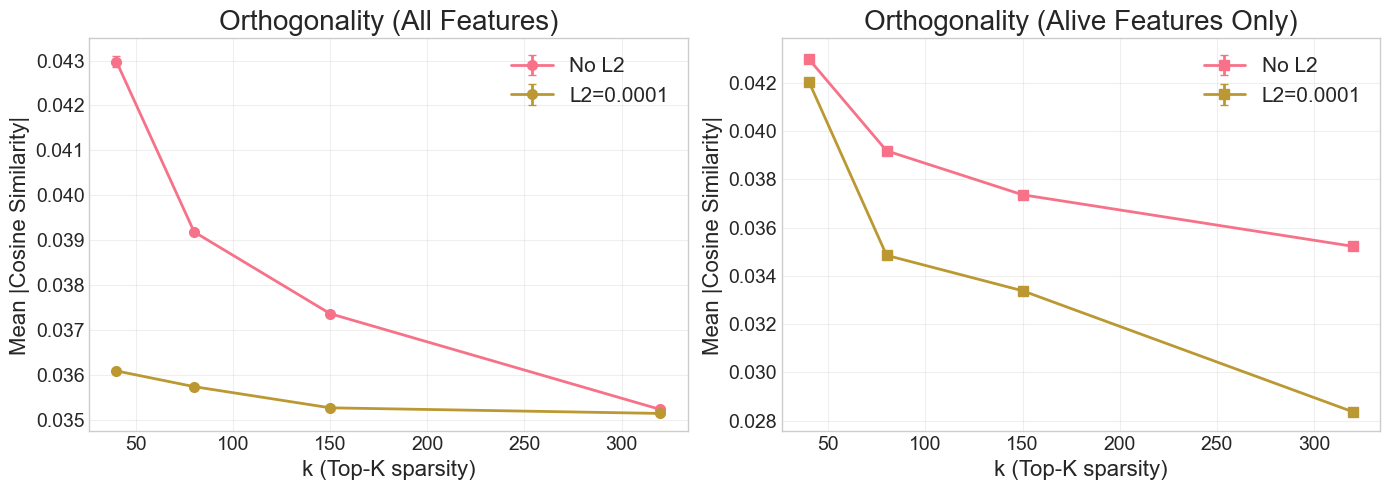

In [11]:
import matplotlib.pyplot as plt

# Define text size parameters for bigger text
BIG_TITLE = 20
BIG_LABEL = 16
BIG_TICK = 14
BIG_LEGEND = 15

plt.rc('axes', titlesize=BIG_TITLE)
plt.rc('axes', labelsize=BIG_LABEL)
plt.rc('xtick', labelsize=BIG_TICK)
plt.rc('ytick', labelsize=BIG_TICK)
plt.rc('legend', fontsize=BIG_LEGEND)

# Plot only the two relevant panels (All features and Alive features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Orthogonality (All Features)
ax = axes[0]
for l2_w in l2_values:
    subset = df_comparison[df_comparison['l2_w'] == l2_w].groupby('k')['mean_abs_cos_all'].agg(['mean', 'std'])
    label = f'L2={l2_w}' if l2_w > 0 else 'No L2'
    ax.errorbar(subset.index, subset['mean'], yerr=subset['std'], 
                marker='o', capsize=3, label=label, linewidth=2, markersize=7)
ax.set_xlabel('k (Top-K sparsity)', fontsize=BIG_LABEL)
ax.set_ylabel('Mean |Cosine Similarity|', fontsize=BIG_LABEL)
ax.set_title('Orthogonality (All Features)', fontsize=BIG_TITLE)
ax.legend(fontsize=BIG_LEGEND)
ax.grid(alpha=0.3)

# Panel 2: Orthogonality (Alive Features Only)
ax = axes[1]
for l2_w in l2_values:
    subset = df_comparison[df_comparison['l2_w'] == l2_w].groupby('k')['mean_abs_cos_alive'].agg(['mean', 'std'])
    label = f'L2={l2_w}' if l2_w > 0 else 'No L2'
    ax.errorbar(subset.index, subset['mean'], yerr=subset['std'], 
                marker='s', capsize=3, label=label, linewidth=2, markersize=7)
ax.set_xlabel('k (Top-K sparsity)', fontsize=BIG_LABEL)
ax.set_ylabel('Mean |Cosine Similarity|', fontsize=BIG_LABEL)
ax.set_title('Orthogonality (Alive Features Only)', fontsize=BIG_TITLE)
ax.legend(fontsize=BIG_LEGEND)
ax.grid(alpha=0.3)

# Bigger text for tick labels
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=BIG_TICK)

plt.tight_layout()
plt.show()


Means and STDs for Orthogonality (All Features) [mean_abs_cos_all]

L2 Weight: 0.0 (No L2)
  k=40: mean=0.042979, std=0.000117
  k=80: mean=0.039182, std=0.000040
  k=150: mean=0.037360, std=0.000060
  k=320: mean=0.035225, std=0.000001

L2 Weight: 0.0001 (L2=0.0001)
  k=40: mean=0.036084, std=0.000007
  k=80: mean=0.035734, std=0.000012
  k=150: mean=0.035262, std=0.000010
  k=320: mean=0.035137, std=0.000004

Means and STDs for Orthogonality (Alive Features Only) [mean_abs_cos_alive]

L2 Weight: 0.0 (No L2)
  k=40: mean=0.042979, std=0.000117
  k=80: mean=0.039182, std=0.000040
  k=150: mean=0.037360, std=0.000060
  k=320: mean=0.035225, std=0.000001

L2 Weight: 0.0001 (L2=0.0001)
  k=40: mean=0.042045, std=0.000173
  k=80: mean=0.034851, std=0.000036
  k=150: mean=0.033383, std=0.000031
  k=320: mean=0.028370, std=0.000077


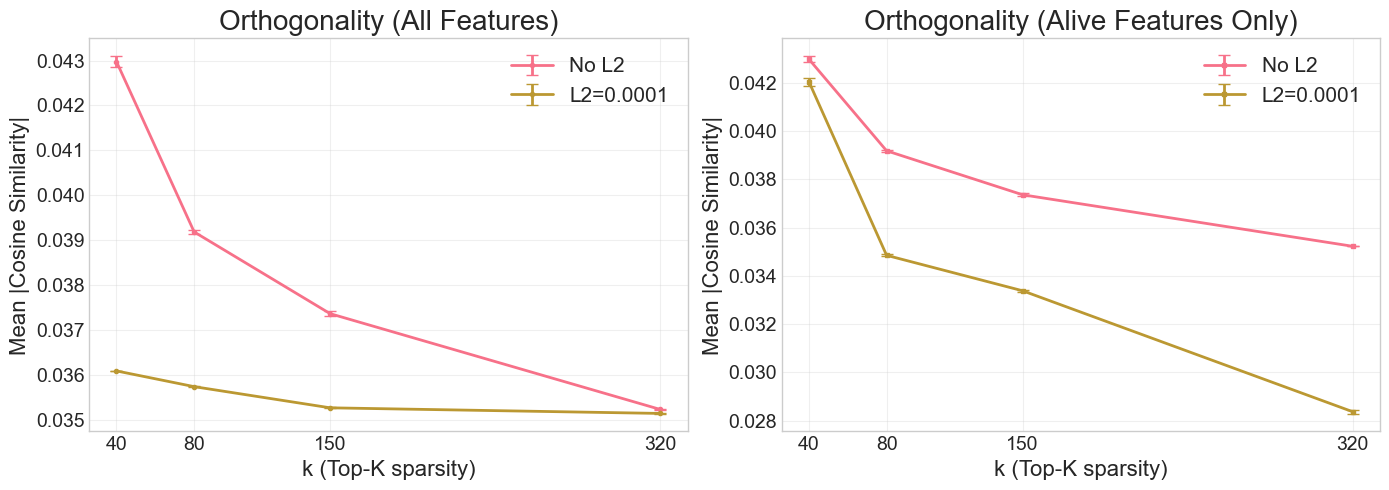

In [16]:
# =============================================================================
# Visualization: Orthogonality Mean and Std by k and L2 (across seeds)
# =============================================================================
# For each k and L2, plot mean and std over all seeds.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

l2_values = sorted(df_comparison['l2_w'].unique())
metrics_to_plot = [
    ('mean_abs_cos_all', 'Orthogonality (All Features)', 'o'),
    ('mean_abs_cos_alive', 'Orthogonality (Alive Features Only)', 's'),
]

# Make the mean data points smaller so that the std bars are more visible
SMALL_MARKERSIZE = 3

for ax, (metric, title, marker) in zip(axes, metrics_to_plot):
    print(f"\n{'='*40}")
    print(f"Means and STDs for {title} [{metric}]")
    print(f"{'='*40}")
    for l2_idx, l2_w in enumerate(l2_values):
        subset = df_comparison[df_comparison['l2_w'] == l2_w]
        # Compute mean and std over all seeds for each k
        agg = subset.groupby('k')[metric].agg(['mean', 'std'])
        label = f'L2={l2_w}' if l2_w > 0 else 'No L2'
        color = f'C{l2_idx}'
        # Print out means and stds for each k
        print(f"\nL2 Weight: {l2_w} ({label})")
        for k_val, row in agg.iterrows():
            print(f"  k={k_val}: mean={row['mean']:.6f}, std={row['std']:.6f}")
        # plot errorbars for mean ± std, with smaller data points
        ax.errorbar(
            agg.index,
            agg['mean'],
            yerr=agg['std'],
            marker=marker,
            capsize=4,
            label=label,
            color=color,
            linewidth=2,
            markersize=SMALL_MARKERSIZE
        )
    ax.set_xlabel('k (Top-K sparsity)', fontsize=BIG_LABEL)
    ax.set_ylabel('Mean |Cosine Similarity|', fontsize=BIG_LABEL)
    ax.set_title(title, fontsize=BIG_TITLE)
    ax.set_xticks(sorted(df_comparison['k'].unique()))
    ax.legend(fontsize=BIG_LEGEND)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=BIG_TICK)

plt.tight_layout()
plt.show()